In [1]:
# Example loading and plotting lidar data of Hybrid Dune Campaign

import numpy as np
import xarray as xr
import os   
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from netCDF4 import Dataset

import sys
sys.path.append('./functions')
from convert_lidar_coordinates_ds_single import convert_lidar_coordinates_ds


In [ ]:
# Example: convert coordinates of a single time step and profile
nc_in = r"O:\HybridDune experiment\data lidar netcdf\storm2_lidar2_polar - new.nc"
ds = xr.open_dataset(nc_in).isel(profile_number=[2,4], t=[1000,1001], echos=[0, 1])   # select specific time range: t0 until t_end

ds_local = convert_lidar_coordinates_ds(ds, 'RD', keep_I=False, max_echos=False)
ds.close()


In [2]:
def filter_pointcloud(nc_in, n_lidar, n_storm, t_sel=None, profile_isel=None):
    # Example loading and filtering lidar data of Hybrid Dune Campaign

    # Define frame angles to be skipped
    # Initialize the array: shape (3, 2, 4, 3)
    hoek_frame_skip = np.zeros((3, 2, 4, 3))
    # S1
    hoek_frame_skip[:, :, 0, 0] = [[-17.4, -14.9], [-13.8, -10.9], [-2.75, 0]]   # storm 1
    hoek_frame_skip[:, :, 0, 1] = [[-16.9, -13.9], [-13.3, -9.9], [-2.25, 0.5]]  # storm 2
    hoek_frame_skip[:, :, 0, 2] = [[-17.4, -14.4], [-13.8, -10.9], [-2.75, 0]]   # storm 3

    # S2
    hoek_frame_skip[:, :, 1, 0] = [[-21.2, -18.2], [-14.3, -11.3], [-2.3, 0.7]]
    hoek_frame_skip[:, :, 1, 1] = [[-20.2, -17.7], [-13.8, -10.8], [-1.3, 1.7]]
    hoek_frame_skip[:, :, 1, 2] = [[-21.2, -18.2], [-14.3, -11.8], [-2.3, 0.7]]

    # S3
    hoek_frame_skip[:, :, 2, 0] = [[-17.0, -14.5], [-12.5, -9.5], [1.0, 4.0]]
    hoek_frame_skip[:, :, 2, 1] = [[-17.0, -14.5], [-12.5, -9.5], [1.0, 4.0]]
    hoek_frame_skip[:, :, 2, 2] = [[-17.5, -14.5], [-12.5, -10.0], [0.5, 4.0]]

    # S4
    hoek_frame_skip[:, :, 3, 0] = [[-19.25, -16.25], [-11.25, -8.75], [-2.75, 0.25]]
    hoek_frame_skip[:, :, 3, 1] = [[-19.25, -16.25], [-11.25, -8.75], [-2.75, 0.25]]
    hoek_frame_skip[:, :, 3, 2] = [[-19.75, -16.75], [-11.75, -8.75], [-3.25, -0.25]]

    # # determine limits to load data from: which vertical angles to select. Between -90° and 105°
    # ds = xr.open_dataset(nc_in).isel(profile_number=0, t=0, echos=0)   # select specific time range: t0 until t_end

    # # # find obs_number with -90° < beam_angle < 105°
    # i_obs_start = np.where(ds.beam_angle.values > -90)[0][0]
    # i_obs_end = np.where(ds.beam_angle.values < 93)[0][-1]
    # print(i_obs_end)

    i_obs_start = 360  # set manually, always the same if looking for the same angles.Here: straight under lidar
    i_obs_end = 545 # for 93deg

    # load data with these obs_number limits
    if (t_sel is  None) and (profile_isel is None):
        ds = xr.open_dataset(nc_in).isel(obs_number=slice(i_obs_start, i_obs_end))                                            # select specific angles
    elif t_sel is None:
        ds = xr.open_dataset(nc_in).isel(profile_number=profile_isel, obs_number=slice(i_obs_start, i_obs_end))               # select specific angles and profile
    elif profile_isel is None:
        ds = xr.open_dataset(nc_in).sel(t=t_sel).isel(obs_number=slice(i_obs_start, i_obs_end))                               # select specific angles and time range
    else:
        ds = xr.open_dataset(nc_in).sel(t=t_sel).isel(profile_number=profile_isel, obs_number=slice(i_obs_start, i_obs_end))  # select specific angles, profile and time range

    # Filter out the frame -----------------------------------------------------------------------
    # Filter out the frame by replacing values in ds.beam_angle with NaN where the laser sees the frame. Then use filtered beam angles for coordianate conversion.

    # Select the slice for given n_lidar and n_storm (Python: 0-based)
    # Example: n_lidar = 1, n_storm = 2 (MATLAB) -> Python: 0, 1
    hoek_frame_skip_slice = hoek_frame_skip[:, :, n_lidar-1, n_storm-1] 

    # Filter frame: loop, for every row in hoek_frame_skip_slice, make angles nan where angles>value_col_1 and angles<value_col_2
    angles = ds.beam_angle.values

    for row in hoek_frame_skip_slice:
        angles[(angles > row[0]) & (angles < row[1])] = np.nan

    ds.beam_angle.values = angles   

    # Convert to local coordinates
    ds = convert_lidar_coordinates_ds(ds, 'local', max_echos=True, keep_I=False, keep_r=True, keep_y=False) # skip intensity, take max distance of echos

    # Define skip area (to remove points below x=6m and above z=-1m)
    x_skip_area = 6.5   # delete every point that is less than 6 m landward of lidar, and (simultaneously) less than 1 m below the lidar
    z_skip_area = -1
    x_min = ds.x_i_local.values + x_skip_area
    z_max = ds.z_i.values + z_skip_area

    # make x, y, z values nan where (x < x_skip_area) & (z > z_skip_area)
    mask_keep = (ds.x.values > x_min) | (ds.z.values < z_max) # keep where either condition is met. So remove where <x_lmin and >z_max
    ds['x'] = ds.x.where(mask_keep)
    #ds['y'] = ds.y.where(mask_keep)
    ds['z'] = ds.z.where(mask_keep)
    ds['radius_lidar'] = ds.radius_lidar.where(mask_keep)

    return ds


In [63]:
# LOAD POINTCLOUD AND FILTER DATA
# INPUT PARAMETERS ----------------------------------------------------------------------------
n_lidar = 1  # set as needed (1-based, like MATLAB)
n_storm = 3 # set as needed (1-based, like MATLAB)

nc_in = fr"O:\HybridDune experiment\data lidar netcdf\storm{n_storm}_lidar{n_lidar}_polar - new.nc"
if n_storm == 1:
    t1 = pd.Timestamp('19-12-2024 02:00')
    t2 = pd.Timestamp('19-12-2024 22:00')
elif n_storm == 2:
    t1 = pd.Timestamp('22-12-2024 04:00')
    t2 = pd.Timestamp('22-12-2024 23:00')
elif n_storm == 3:
    t1 = pd.Timestamp('01-01-2025 12:00')
    t2 = pd.Timestamp('02-01-2025 09:00')
else:
    raise ValueError('n_storm must be 1, 2, or 3')

# LOAD AND FILTER POINTCLOUD ----------------------------------------------------------------------------
#ds.close()
ds = filter_pointcloud(nc_in, n_lidar, n_storm, t_sel=slice(t1, t2), profile_isel=2) # Filter out frame and high waves (points less than 1 m below lidar and offshore of dune toe)
ds = ds.drop_vars(['x','z'])

# EXTRACT DUNE PROFILES FROM POINTCLOUDS ----------------------------------------------------------------------------
# take moving max radius over X minutes, ignore NaNs
dt_minutes = 10
window_length = np.int16(dt_minutes * 60 * ds.sf.values) # 5 minutes * 60 seconds * 4 Hz
ds['radius_lidar'] = ds.radius_lidar.rolling(t=window_length, center=True, min_periods=1).max()   # min_periods=1: 1 non-nan value is enough. So A) ignore nans and b) ignore window edges

In [66]:
# Select one point cloud per window: For each instant in time_vector, select the first t >= time_vector[i]
time_vector = pd.date_range(start=t1, end=t2, freq=f'{dt_minutes}min')
time_vector = pd.date_range(start=t1, end=t2, freq='10min')

t_vals = pd.to_datetime(ds.t.values)
selected_indices = []
for t_ref in time_vector:
    idx = np.searchsorted(t_vals, t_ref, side='left')
    if idx < len(t_vals):
        selected_indices.append(idx)

ds_plot = ds.isel(t=selected_indices)

# Remove outliers: make r nan where the difference between consecutive r values over dim obs_number is larger than 0.5 m
mask_full = xr.DataArray(np.ones_like(ds_plot.radius_lidar, dtype=bool), dims=ds_plot.radius_lidar.dims, coords=ds_plot.radius_lidar.coords)  # pre-define mask: size of ds.radius_lidar, true everywhere
r_diff = ds_plot.radius_lidar.diff(dim='obs_number')                     # Calculate the difference between consecutive values
mask = np.abs(r_diff) <= 0.5                                        # Create a mask: True where the difference is <= 0.5, False where it's an outlier
mask_full.values[1:,:] = mask.values                                # Combine the mask
ds_plot['radius_lidar'] = ds_plot.radius_lidar.where(mask_full)               # Apply the mask: set outliers to NaN

# Recalculate x and z, based on the max r per window
ds_plot = convert_lidar_coordinates_ds(ds_plot, 'local', max_echos=False, keep_I=False, keep_r=False, keep_y=False) # skip intensity, take max distance of echos

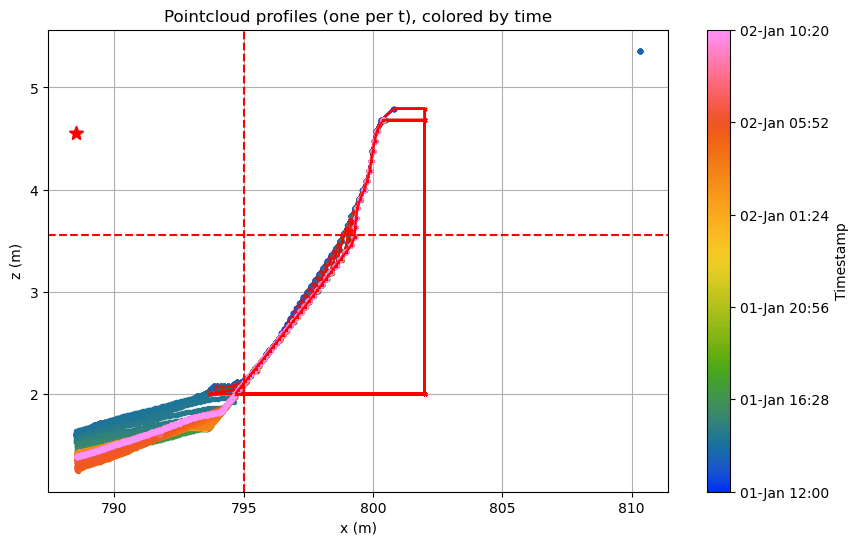

In [69]:
import colorcet as cc   # For color maps

# Plot data
x_construction = np.array([803.11, 791.69])
z_construction = np.array([  4.77,   1.07])

# plot pointcloud as profiles: one line per t, colored by timestamp
fig, ax = plt.subplots(figsize=(10, 6))

t_vals = pd.to_datetime(ds_plot.t.values)
norm = plt.Normalize(mdates.date2num(t_vals).min(), mdates.date2num(t_vals).max())
#cmap = plt.get_cmap('viridis')
cmap = plt.get_cmap('cet_CET_R1')

for i, t in enumerate(t_vals):
    color = cmap(norm(mdates.date2num(t)))
    ax.plot(ds_plot.x[:, i], ds_plot.z[:, i], marker='o', markersize=3, linestyle='-', color=color)

    # plot polygon of dune area
    x = ds_plot.x[:, i].values
    z = ds_plot.z[:, i].values
    # filter: select only non-nan x
    x = x[~np.isnan(x)]
    z = z[~np.isnan(z)]

    # # # select x, z where x>793
    # i = (x>793) & (x<802)
    # x = x[i]
    # z = z[i]

    # # pad: make a triangle
    # x = np.concatenate(([793, 793 ], x, [802,   802, 793]))
    # z = np.concatenate(([1.5, z[0]], z, [z[-1], 1.5, 1.5]))

    # select x, z where x>793
    i = (z>2) & (x<802)
    x = x[i]
    z = z[i]

    # pad: make a triangle
    x = np.concatenate(([x[0]], x, [802, 802, x[0]]))
    z = np.concatenate(([2], z, [z[-1], 2, 2]))
    plt.plot(x, z, marker='x', markersize=2, linestyle='-', color='red')


sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
n_ticks = 6
tick_locs = np.linspace(mdates.date2num(t_vals).min(), mdates.date2num(t_vals).max(), n_ticks)
tick_labels = [mdates.num2date(t).strftime('%d-%b %H:%M') for t in tick_locs]
cbar.set_ticks(tick_locs)
cbar.set_ticklabels(tick_labels)
cbar.set_label('Timestamp')

# Plot the lidar and construction
ax.plot(ds_plot.x_i_local.values, ds_plot.z_i.values, color='red', marker='*', markersize=10, linestyle='None', label='Lidar')
#ax.plot(x_construction, z_construction, color='black', label='Revetment')
# plot a vertical line at ds.x_i_local.values
ax.axvline(x=ds_plot.x_i_local.values+6.5, color='red', linestyle='--', label='Lidar position')
ax.axhline(y=ds_plot.z_i.values-1, color='red', linestyle='--', label='Lidar position')
ax.scatter(ds_plot.x_i_local.values, ds_plot.z_i.values, color='red', marker='*', s=100, label='Lidar')
ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
ax.set_title('Pointcloud profiles (one per t), colored by time')
ax.grid()
#ax.set_xlim(800, 801)
#ax.set_ylim(4.6, 4.8)
plt.show()


In [70]:
# LOAD POINTCLOUD AND FILTER DATA
# INPUT PARAMETERS ------------------------------------------------------------------------------------------------
n_lidar = 1  # set as needed (1-based, like MATLAB)

for n_storm in [1, 2, 3]:
#n_storm = 1 # set as needed (1-based, like MATLAB)

    nc_in = fr"O:\HybridDune experiment\data lidar netcdf\storm{n_storm}_lidar{n_lidar}_polar - new.nc"
    if n_storm == 1:
        t1 = pd.Timestamp('19-12-2024 02:00')
        t2 = pd.Timestamp('19-12-2024 22:09')
    elif n_storm == 2:
        t1 = pd.Timestamp('22-12-2024 04:00')
        t2 = pd.Timestamp('22-12-2024 23:09')
    elif n_storm == 3:
        t1 = np.datetime64('2025-01-01T12:00')
        t2 = np.datetime64('2025-01-02T09:09')  # ensure that Jan 2 is selected, not Feb 1
    else:
        raise ValueError('n_storm must be 1, 2, or 3')

    # LOAD AND FILTER POINTCLOUD ----------------------------------------------------------------------------------------
    #ds.close()
    ds = filter_pointcloud(nc_in, n_lidar, n_storm, t_sel=slice(t1, t2), profile_isel=2) # Filter out frame and high waves (points less than 1 m below lidar and offshore of dune toe)
    ds = ds.drop_vars(['x','z'])

    # EXTRACT DUNE PROFILES FROM POINTCLOUDS ----------------------------------------------------------------------------
    # take moving max radius over X minutes, ignore NaNs
    dt_minutes = 10
    window_length = np.int16(dt_minutes * 60 * ds.sf.values) # 5 minutes * 60 seconds * 4 Hz
    ds['radius_lidar'] = ds.radius_lidar.rolling(t=window_length, center=True, min_periods=1).max()   # min_periods=1: 1 non-nan value is enough. So A) ignore nans and b) ignore window edges

    # Select one point cloud per window: For each instant in time_vector, select the first t >= time_vector[i]
    #time_vector = pd.date_range(start=t1, end=t2, freq=f'{dt_minutes}min')
    time_vector = pd.date_range(start=t1, end=t2, freq='20min')

    t_vals = pd.to_datetime(ds.t.values)
    selected_indices = []
    for t_ref in time_vector:
        idx = np.searchsorted(t_vals, t_ref, side='left')
        if idx < len(t_vals):
            selected_indices.append(idx)

    ds_plot = ds.isel(t=selected_indices)

    # Remove outliers: make r nan where the difference between consecutive r values over dim obs_number is larger than 0.5 m
    mask_full = xr.DataArray(np.ones_like(ds_plot.radius_lidar, dtype=bool), dims=ds_plot.radius_lidar.dims, coords=ds_plot.radius_lidar.coords)  # pre-define mask: size of ds.radius_lidar, true everywhere
    r_diff = ds_plot.radius_lidar.diff(dim='obs_number')                     # Calculate the difference between consecutive values
    mask = np.abs(r_diff) <= 0.5                                        # Create a mask: True where the difference is <= 0.5, False where it's an outlier
    mask_full.values[1:,:] = mask.values                                # Combine the mask
    ds_plot['radius_lidar'] = ds_plot.radius_lidar.where(mask_full)               # Apply the mask: set outliers to NaN

    # Recalculate x and z, based on the max r per window
    ds_plot = convert_lidar_coordinates_ds(ds_plot, 'local', max_echos=False, keep_I=False, keep_r=False, keep_y=False) # skip intensity, take max distance of echos

    # CALCULATE DUNE VOLUME: THE VOLUME UNDERTHE PROFILE-------------------------------------------------------------------
    # calculate area using shoelace formula
    def polygon_area(x, z):
        return 0.5 * np.abs(np.dot(x, np.roll(z, 1)) - np.dot(z, np.roll(x, 1)))

    # Loop over all t and calculate dune volume for each profile.           V1: x>793--------------------------------------
    volumes = []
    for n_t in range(ds_plot.x.shape[1]):
        x = ds_plot.x[:, n_t].values
        z = ds_plot.z[:, n_t].values

        # filter: select only non-nan x
        mask = ~np.isnan(x)
        x = x[mask]
        z = z[mask]

        # select x, z where x>793 and x<802
        i = (x > 793) & (x < 802)
        x = x[i]
        z = z[i]

        if len(x) == 0:
            volumes.append(np.nan)
            continue
        if n_storm == 1 & n_lidar==2:
            x = np.concatenate(( x, [x[-1]+0.12] ))
            z = np.concatenate(( z, [4.79] ))
        elif n_storm==3 & n_lidar==2:
            x = np.concatenate((x, [min(800.45, x[-1] + 0.15)]))
            z = np.concatenate((z, [4.85]))
        elif n_storm==3 & n_lidar==1:
            x = np.concatenate((x, [min(800.45, x[-1] + 0.55)]))
            z = np.concatenate((z, [4.79]))
                        
        # pad: make a triangle
        x = np.concatenate(([793, 793], x, [802, 802, 793]))
        z = np.concatenate(([1.5, z[0]], z, [z[-1], 1.5, 1.5]))

        # Calculate dune volume
        area = polygon_area(x, z)
        volumes.append(area)

    # Calculate erosion_volume: 0 for t=0, then difference in volume for all subsequent steps
    volumes = np.array(volumes)
    erosion_volume = np.zeros_like(volumes)
    erosion_volume[:-1] = volumes[:-1] - volumes[1:] # erosion at time t is V(t) - V(t+1). Or -E = dV = V(t+1)-V(t)

    # Assign erosion_volume to ds for every t, with attribute 'Units' = 'm3/m'
    ds_plot['erosion_volume1'] = (('t',), erosion_volume)
    ds_plot['erosion_volume1'].attrs['Units'] = 'm3/m'

    # Loop over all t and calculate dune volume for each profile.           V2: z>2---------------------------------------
    volumes = []
    for n_t in range(ds_plot.x.shape[1]):
        x = ds_plot.x[:, n_t].values
        z = ds_plot.z[:, n_t].values

        # filter: select only non-nan x
        mask = ~np.isnan(x)
        x = x[mask]
        z = z[mask]

        # select x, z where x>793 and x<802
        i = (z > 2) & (x < 802)
        x = x[i]
        z = z[i]

        if len(x) == 0:
            volumes.append(np.nan)
            continue
        if n_storm == 1:
            x = np.concatenate(( x, [x[-1]+0.12] ))
            z = np.concatenate(( z, [4.79] ))
        elif n_storm==3:
            x = np.concatenate((x, [min(800.45, x[-1] + 0.15)]))
            z = np.concatenate((z, [4.85]))
            
        # pad: make a triangle
        x = np.concatenate(( [x[0]], x, [802,   802, x[0]] ))
        z = np.concatenate(( [2],    z, [z[-1], 2,   2   ] ))

        # Calculate dune volume
        area = polygon_area(x, z)
        volumes.append(area)

    # Calculate erosion_volume: 0 for t=0, then difference in volume for all subsequent steps
    volumes = np.array(volumes)
    erosion_volume = np.zeros_like(volumes)
    erosion_volume[:-1] = volumes[:-1] - volumes[1:]

    # Assign erosion_volume to ds for every t, with attribute 'Units' = 'm3/m'
    ds_plot['erosion_volume2'] = (('t',), erosion_volume)
    ds_plot['erosion_volume2'].attrs['Units'] = 'm3/m'
    print("Erosion volumes assigned to ds['erosion_volume'].")

    if n_storm == 1:
        ds1=ds_plot.copy()
    elif n_storm == 2:
        ds2=ds_plot.copy()
    elif n_storm == 3:
        ds3=ds_plot.copy()

Erosion volumes assigned to ds['erosion_volume'].
Erosion volumes assigned to ds['erosion_volume'].
Erosion volumes assigned to ds['erosion_volume'].
Erosion volumes assigned to ds['erosion_volume'].
Erosion volumes assigned to ds['erosion_volume'].


In [77]:
ds_rbr_sel.t_block

<xarray.DataArray 't_block' (t_block: 0)> Size: 0B
array([], dtype='datetime64[ns]')
Coordinates:
  * t_block  (t_block) datetime64[ns] 0B

In [78]:
# Add hydrodynamic data from RBR netcdf file --------------------------------------------------------
for n_storm in [1, 2, 3]:
    # Select lidar dataset 
    if n_storm == 1:
        ds_plot = ds1.copy()
        t1 = pd.Timestamp('19-12-2024 02:00')
        t2 = pd.Timestamp('19-12-2024 22:09')
    elif n_storm == 2:
        ds_plot = ds2.copy()
        t1 = pd.Timestamp('22-12-2024 04:00')
        t2 = pd.Timestamp('22-12-2024 23:09')
    elif n_storm == 3:
        ds_plot = ds3.copy()
        t1 = np.datetime64('2025-01-01T12:00')
        t2 = np.datetime64('2025-01-02T09:09')  # ensure that Jan 2 is selected, not Feb 1
    else:
        raise ValueError('n_storm must be 1, 2, or 3')
    
    if n_storm <= 2:
        nc_rbr = r'O:\HybridDune experiment\data RBR, OSSI\netcdf\processed\Deployment period 1\Pressure sensor S3P3 RBR6 processed data - period 1.nc'
    else:
        nc_rbr = r'O:\HybridDune experiment\data RBR, OSSI\netcdf\processed\Deployment period 2\Pressure sensor S3P3 RBR6 processed data - period 2.nc'
    ds_rbr = xr.open_dataset(nc_rbr)

    ds_rbr_sel = ds_rbr.sel(t_block=slice(t1, t2))

    # compare the time steps in both datasets
    # Round time values to the nearest 10s to avoid floating point issues
    t_round = pd.to_datetime(ds_plot.t.values).round('10s')
    if ~(ds_rbr_sel.t_block.values == t_round.values).all():
        # give error
        raise ValueError('Time steps in RBR and Lidar datasets do not match.')

    ds_plot['zs_mean'] = (('t',), ds_rbr_sel.zs_mean.values)
    ds_plot['zs_mean'].attrs = ds_rbr_sel.zs_mean.attrs

    ds_plot['Hm0'] = (('t',), ds_rbr_sel.Hm0.values)
    ds_plot['Hm0'].attrs = ds_rbr_sel.Hm0.attrs

    ds_plot['Tp'] = (('t',), ds_rbr_sel.Tps.values) # Tps: smoothed Tp
    ds_plot['Tp'].attrs = ds_rbr_sel.Tps.attrs

    beta = 0.04  # beach slope, set as needed
    L = (9.81 * ds_plot.Tp**2) / (2 * np.pi)  # deep water wavelength, assuming Tp S3P3 is deep water
    ksi = beta / np.sqrt(ds_plot.Hm0 / L) # irrabaren number
    eta_u = 0.35 * ds_plot.Hm0 * ksi # wave setup
    Sw    = 0.75 * ds_plot.Hm0 * ksi # runup wind waves
    Sig   = 0.06* (ds_plot.Hm0 * L)**0.5  # runup IG waves

    r2procent_A = (1.1 * (eta_u + Sw) + 1.7 * Sig)
    r2procent_B = 0.043 * (ds_plot.Hm0 * L)**0.5

    # r_A is ksi>=0.3, r_B is ksi<0.3
    # r2procent = xr.where(ksi >= 0.3, r2procent_A, r2procent_B)  # skip: huge effect from ksi just above or below 0.3
    r2procent = r2procent_A
    

    ds_plot['ksi'] = ksi
    ds_plot['ksi'].attrs = {'long_name': 'Iribarren number', 'units': '-'}

    ds_plot['r2procent'] =r2procent
    ds_plot['r2procent'].attrs = {'long_name': '2% runup', 'units': 'm above still water level'}

    ds_plot['r2procent_NAP'] = ds_plot.r2procent + ds_plot.zs_mean
    ds_plot['r2procent_NAP'].attrs = {'long_name': '2% runup height in NAP', 'units': 'm NAP'}

    # Assign back to storm datasets
    if n_storm == 1:
        ds1=ds_plot.copy()
    elif n_storm == 2:
        ds2=ds_plot.copy()
    elif n_storm == 3:
        ds3=ds_plot.copy()

In [ ]:
# PLOT DUNE EROSION FROM BOTH METHODS
# SCATTER OF ds.erosion_volume1 VS ds.erosion_volume2 fords1, ds2 and ds3, in 3 subplots
fig, axs = plt.subplots(3, 1, figsize=(8, 12))
for i, ds in enumerate([ds1, ds2, ds3]):
    ax = axs[i]
    ax.scatter(ds.erosion_volume1, ds.erosion_volume2, color='blue', alpha=0.7)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_ylabel('Erosion Volume Method 2 (m3/m)')
    ax.set_title(f'Storm {i+1}: Erosion Volume Comparison')
    ax.grid()
    ax.set_xlim(-0.25, 0.75)
    ax.set_ylim(-0.25, 0.75)
ax.set_xlabel('Erosion Volume Method 1 (m3/m)')


# TO DO LATER: EXAMINE MOMENT WHEN LARGE DIFFERENCES OCCUR BETWEEN METHODS    

(1.3, 2.25)

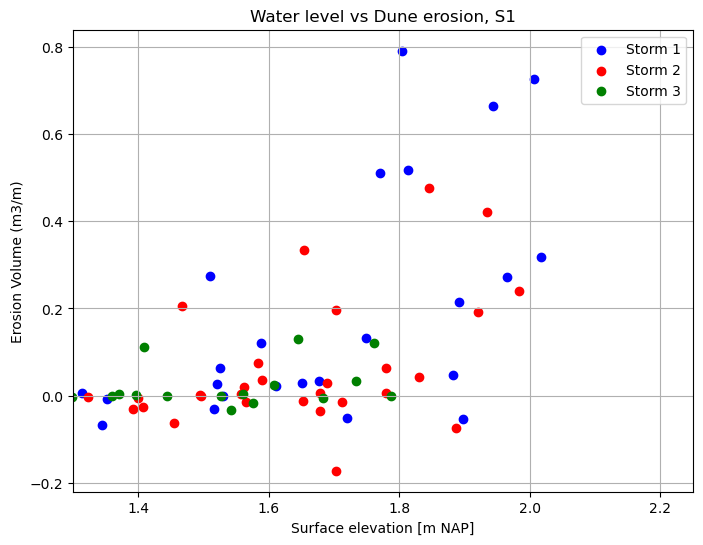

In [79]:
# correlation plot: zs vs erosion_volume, colored by time
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(ds1.zs_mean, ds1.erosion_volume2, color='blue', marker='o', label='Storm 1')
sc = ax.scatter(ds2.zs_mean, ds2.erosion_volume2, color='red', marker='o', label='Storm 2')
sc = ax.scatter(ds3.zs_mean, ds3.erosion_volume2, color='green', marker='o', label='Storm 3')

ax.set_xlabel('Surface elevation [m NAP]')
ax.set_ylabel('Erosion Volume (m3/m)')
ax.set_title('Water level vs Dune erosion, S1')
ax.grid()
ax.legend()
ax.set_xlim(1.3, 2.25)


(1.3, 2.25)

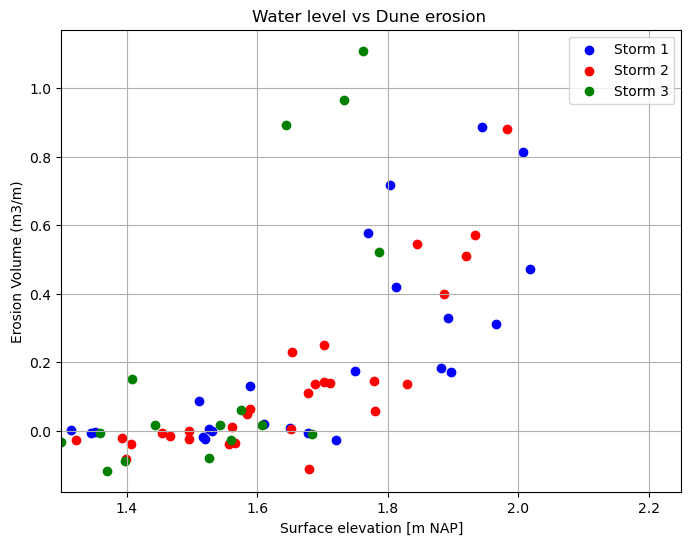

In [8]:
# correlation plot: zs vs erosion_volume, colored by time
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(ds1.zs_mean, ds1.erosion_volume2, color='blue', marker='o', label='Storm 1')
sc = ax.scatter(ds2.zs_mean, ds2.erosion_volume2, color='red', marker='o', label='Storm 2')
sc = ax.scatter(ds3.zs_mean, ds3.erosion_volume2, color='green', marker='o', label='Storm 3')

ax.set_xlabel('Surface elevation [m NAP]')
ax.set_ylabel('Erosion Volume (m3/m)')
ax.set_title('Water level vs Dune erosion ')
ax.grid()
ax.legend()
ax.set_xlim(1.3, 2.25)


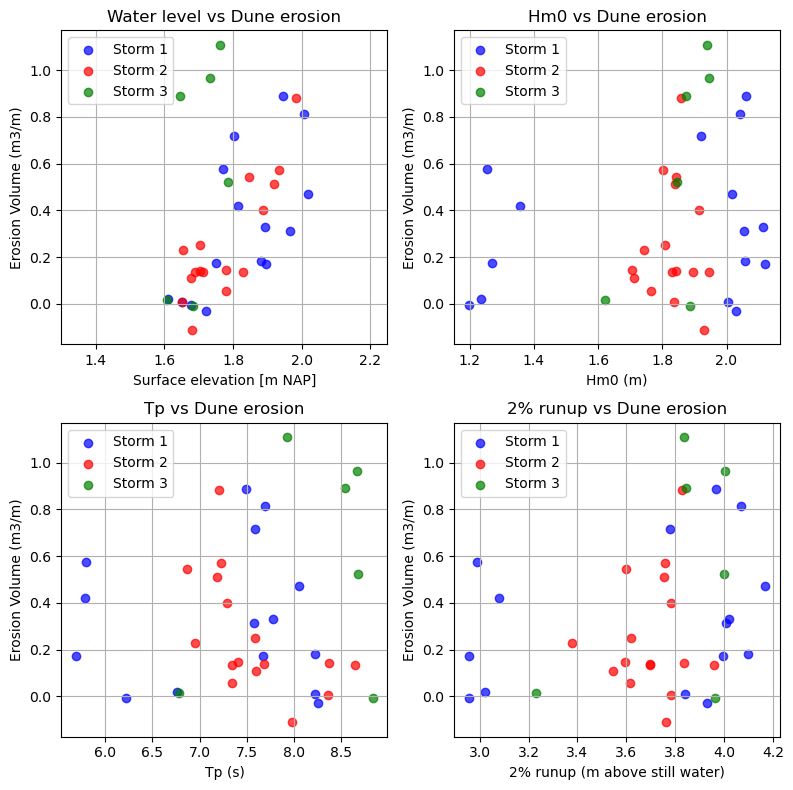

In [31]:
# Correlation plots: filter zs_mean > 1.6, plot 4 variables vs erosion_volume2
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
storm_colors = ['blue', 'red', 'green']
storm_labels = ['Storm 1', 'Storm 2', 'Storm 3']
storm_datasets = [ds1, ds2, ds3]

# Define variables and axis labels
var_names = ['zs_mean', 'Hm0', 'Tp', 'r2procent_NAP']
xlabels = [
    'Surface elevation [m NAP]',
    'Hm0 (m)',
    'Tp (s)',
    '2% runup (m above still water)'
]
titles = [
    'Water level vs Dune erosion',
    'Hm0 vs Dune erosion',
    'Tp vs Dune erosion',
    '2% runup vs Dune erosion'
 ]

for i, (var, xlabel, title) in enumerate(zip(var_names, xlabels, titles)):
    ax = axs.flat[i]
    for ds, color, label in zip(storm_datasets, storm_colors, storm_labels):
        # Filter for zs_mean > 1.6
        mask = ds.zs_mean > 1.6
        x = ds[var].values[mask]
        y = ds.erosion_volume2.values[mask]
        ax.scatter(x, y, color=color, marker='o', label=label, alpha=0.7)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Erosion Volume (m3/m)')
    ax.set_title(title)
    ax.grid()
    if var == 'zs_mean':
        ax.set_xlim(1.3, 2.25)
    ax.legend()

plt.tight_layout()

Text(0, 0.5, 'Erosion Volume (m3/m)')

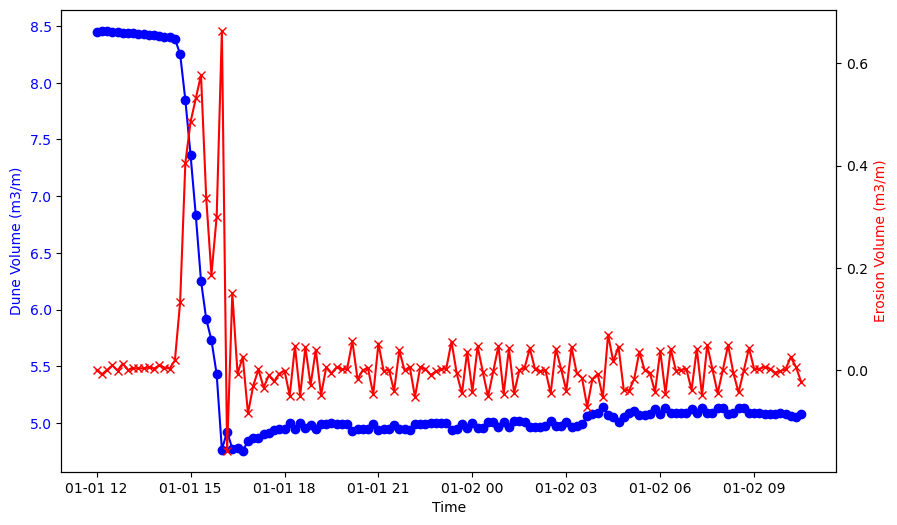

In [98]:
# plot volume and erosioin_volume over time
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(pd.to_datetime(ds3.t.values), volumes, color='blue', marker='o', label='Dune Volume (m3/m)')
ax1.set_xlabel('Time')  
ax1.set_ylabel('Dune Volume (m3/m)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax2 = ax1.twinx()
ax2.plot(pd.to_datetime(ds3.t.values), erosion_volume, color='red', marker='x', label='Erosion Volume (m3/m)')
ax2.set_ylabel('Erosion Volume (m3/m)', color='red')    

In [66]:
nc_rbr = r'O:\HybridDune experiment\data RBR, OSSI\netcdf\processed\Deployment period 1\Pressure sensor S3P3 RBR6 processed data - period 1.nc'

ds_rbr = xr.open_dataset(nc_rbr)


In [ ]:
# plot zs
zs.plot()

In [ ]:
# plot volume and erosioin_volume over time
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(pd.to_datetime(zs.t_full.values), zs, color='blue', marker='o', label='Surface elevation [m NAP]')
ax1.set_xlabel('Time')  
ax1.set_ylabel('Surface elevation [m NAP]', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax2 = ax1.twinx()
ax2.plot(pd.to_datetime(ds.t.values), erosion_volume, color='red', marker='x', label='Erosion Volume (m3/m)')
ax2.set_ylabel('Erosion Volume (m3/m)', color='red')  




In [ ]:
# correlation plot: zs vs erosion_volume, colored by time
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(8, 6))
times = pd.to_datetime(ds.t.values)
c = mdates.date2num(times)
sc = ax.scatter(zs, erosion_volume, c=c, cmap='viridis', marker='o')
ax.set_xlabel('Surface elevation [m NAP]')
ax.set_ylabel('Erosion Volume (m3/m)')
ax.set_xlim(1.3, 2.25)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Time')
tick_locs = np.linspace(c.min(), c.max(), 6)
tick_labels = [mdates.num2date(t).strftime('%d-%b %H:%M') for t in tick_locs]
cbar.set_ticks(tick_locs)
cbar.set_ticklabels(tick_labels)

In [ ]:
nc_in = r'O:\HybridDune experiment\2024-12-22, Storm 2\Lidars\20241223_LiDAR2\storm2_lidar2_polar.nc'
nc_out = r'O:\HybridDune experiment\2024-12-22, Storm 2\Lidars\20241223_LiDAR2\storm2_lidar2_polar_temp.nc'
ds = xr.open_dataset(nc_in).isel(time=slice(0,10))   # select specific time range: t0 until t_end
ds
ds.to_netcdf(nc_out)